In [28]:
# Parameters
param1=1

In [29]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy


from torch import nn
from umap import UMAP

from run_sim import Config, run_sim
from utils import cosine_similarity, get_r_2, vector_angle
from tqdm import tqdm
from tqdm import tqdm
from utils import alignment_score, calc_PR, calc_NC1
import matplotlib as mpl
from functools import reduce



In [30]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [31]:
C = Config()

C.sig_h_2 = 1e-1
C.linear_net = True
C.learning_rate = 0.01
C.L=5
C.print_progress = True
C.length_corridors = [30]*1
C.max_move = 15
C.hidden_size = 100 
C.num_epochs = 10000
C.algo_name = 'SGD'
C.loss_fn = nn.CrossEntropyLoss()

In [32]:


X, y, corridor, loc_X, loc_y, action_taken, hidden_states, loss_l, accuracy_l, outputs, hidden_l, final_weights, initial_weights = run_sim(C)

print(calc_h_var(C.G, X.shape[1], C.hidden_size, C.L, X.var().cpu().numpy()))
hidden = hidden_states[-1].detach().cpu().numpy()
X_dist = torch.cdist(X, X).cpu().numpy()
y_dist = torch.cdist(y, y).cpu().numpy()
hidden_dist = torch.cdist(hidden_states[-1].detach(), hidden_states[-1].detach()).cpu().numpy()
stay_inds = np.where(action_taken == 0)[0]
loc_y_corridor = loc_y + (corridor * max(loc_y + 1))
n_corridors = len(C.length_corridors)

X_np = X.cpu().numpy()  # Convert to numpy array if X is a torch tensor
y_np = y.cpu().numpy()  # Convert to numpy array if y is a torch tensor
h_np = hidden  # Convert to numpy array if hidden is a torch tensor

Number of samples: 690
Input dimension: 61
Output dimension: 30
Number of actions: 31

Changed G to 1.1532496213912964 to get sig_h_2 = 0.1
Sig_2 of last hidden: 0.10252900421619415


100%|██████████| 10000/10000 [00:39<00:00, 255.13it/s]

0.09999995747001739


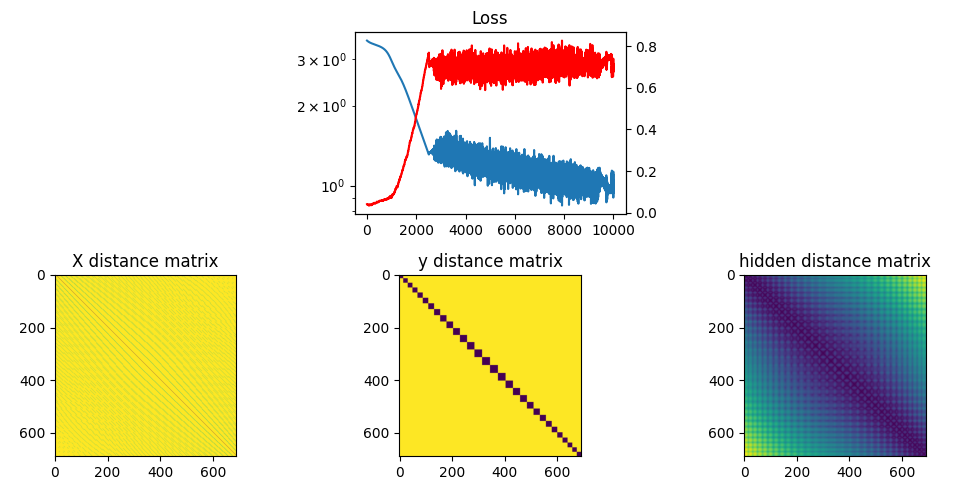

In [33]:
indices = np.lexsort((loc_y, corridor))
# indices = indices[action_taken[indices]==0]
fig, axs = plt.subplots(2, 3, figsize=(10, 5))
axs[0,0].set_axis_off(); axs[0,2].set_axis_off()
axs[0,1].plot(loss_l)
axs[0,1].set_yscale('log')
axs[0,1].twinx().plot(accuracy_l, 'r')
axs[0,1].set_title("Loss")
for var, var_name, ax in zip([X_dist, y_dist, hidden_dist], ['X', 'y', 'hidden'], axs[1]):
    ax.imshow(var[indices][:, indices], cmap='viridis')
    ax.set_title(f'{var_name} distance matrix')
    ax.grid(False)
plt.tight_layout()
plt.show()

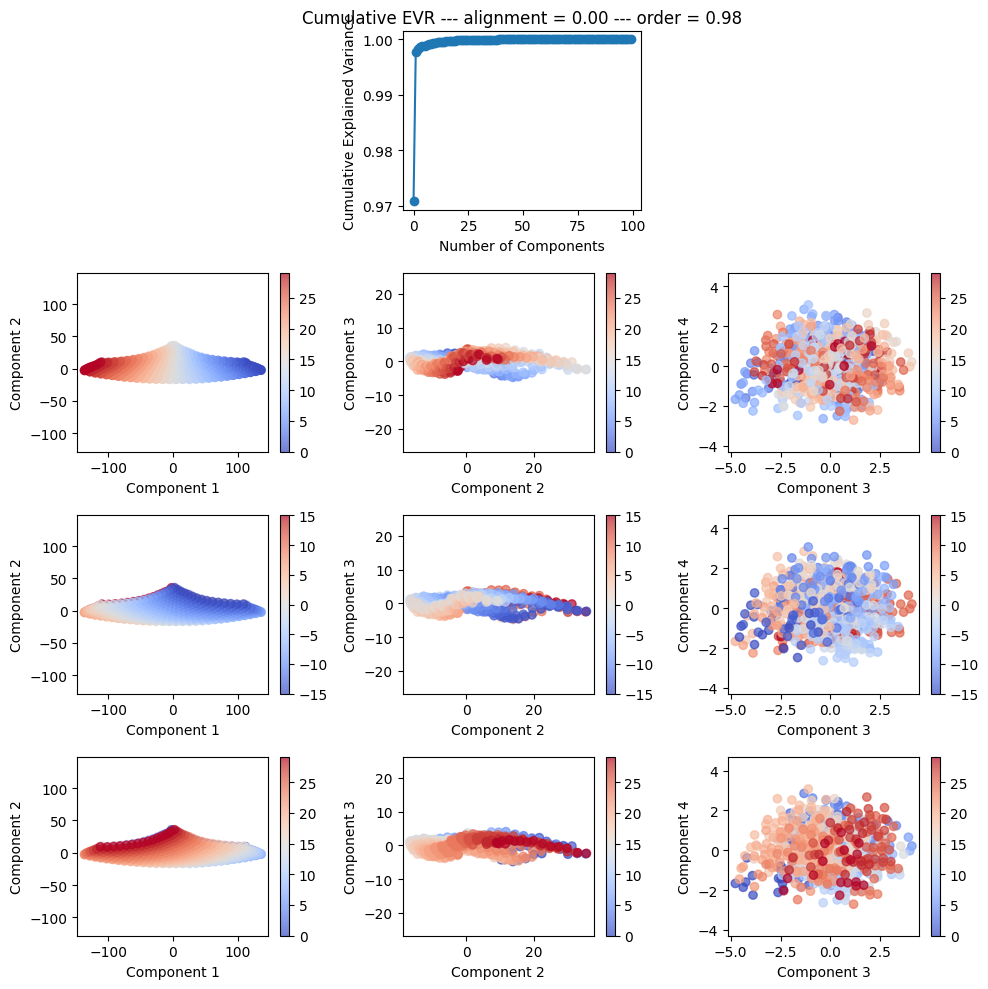

In [ ]:
pca = PCA().fit(h_np)
# pca_corridors = [PCA() for i in range(n_corridors)]
# [p.fit(hidden[corridor==i]) for i, p in enumerate(pca_corridors)]
# alignment = np.mean([[cosine_similarity(pca_corridors[i].components_[0], pca_corridors[j].components_[0]) for j in
#                       range(n_corridors) if j!=i] for i in range(n_corridors)])
alignment = alignment_score(hidden[corridor==0], hidden[corridor==1]) if n_corridors > 1 else 0
order = get_r_2(PCA(n_components=1).fit_transform(hidden), loc_y)
X_reduced = pca.transform(h_np)
fig = plt.figure(figsize=(10, 10))

markers = list(mpl.markers.MarkerStyle.markers.keys())[2:]
# Add cumulative explained variance ratio in the first row
ax1 = fig.add_subplot(4, 3, 2)
ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title(f'Cumulative EVR --- alignment = {alignment:.2f} --- order = {order:.2f}')

# Add scatter plots in the second row
for i in range(3):
    for j, c in enumerate([loc_y, action_taken, loc_X]):
        ax = fig.add_subplot(4, 3, i + 4 + j*3)
        # c = loc_y
        # c = action_taken[inds]
        for n in range(n_corridors):
            s = ax.scatter(X_reduced[corridor==n, i], X_reduced[corridor==n, i+1], c=c[corridor==n], cmap='coolwarm', alpha=0.7, marker=markers[n])
        ax.set_xlabel(f'Component {i+1}')
        ax.set_ylabel(f'Component {i+2}'),
        ax.axis('equal')
        fig.colorbar(s, ax=ax)

plt.tight_layout()
plt.show()